In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from  datetime import datetime
import pandas as pd
import plotly.express as px


mpl.rcParams['figure.figsize'] = (10, 8)
mpl.rcParams['axes.grid'] = False

In [3]:
df = pd.read_csv('/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/ML Micro Projects/data/raw/nyc_energy_consumption.csv')

In [4]:
df

,timeStamp,demand,precip,temp
0,2012-01-01 00:00:00,4937.5,0.0000,46.13
1,2012-01-01 01:00:00,4752.1,0.0000,45.89
2,2012-01-01 02:00:00,4542.6,0.0000,45.04
3,2012-01-01 03:00:00,4357.7,0.0000,45.03
4,2012-01-01 04:00:00,4275.5,0.0000,42.61
...,...,...,...,...
49200,2017-08-12 02:00:00,NaN,0.0000,70.84
49201,2017-08-12 03:00:00,NaN,0.0000,70.57
49202,2017-08-12 04:00:00,NaN,0.0000,69.89
49203,2017-08-12 05:00:00,NaN,0.0000,68.59


In [5]:
df['timeStamp'] = pd.to_datetime(df['timeStamp'])

In [6]:
df

,timeStamp,demand,precip,temp
0,2012-01-01 00:00:00,4937.5,0.0000,46.13
1,2012-01-01 01:00:00,4752.1,0.0000,45.89
2,2012-01-01 02:00:00,4542.6,0.0000,45.04
3,2012-01-01 03:00:00,4357.7,0.0000,45.03
4,2012-01-01 04:00:00,4275.5,0.0000,42.61
...,...,...,...,...
49200,2017-08-12 02:00:00,NaN,0.0000,70.84
49201,2017-08-12 03:00:00,NaN,0.0000,70.57
49202,2017-08-12 04:00:00,NaN,0.0000,69.89
49203,2017-08-12 05:00:00,NaN,0.0000,68.59


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49205 entries, 0 to 49204
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timeStamp  49205 non-null  datetime64[ns]
 1   demand     49124 non-null  float64       
 2   precip     48975 non-null  float64       
 3   temp       49019 non-null  float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 1.5 MB


In [8]:
fig = px.line(df, x='timeStamp', y='demand', title='NYC Enery Demand')

fig.update_xaxes(
    rangeslider_visible = True,
    rangeselector = dict(
        buttons = [
            dict(count = 1, label = '1y', step = 'year', stepmode = 'backward'),
            dict(count=2, label = '2y', step = 'year', stepmode = 'backward'),
            dict(count=3, label = '3y', step = 'year', stepmode= 'backward'),
            dict(step ='all')
        ]

    )
)
fig.show()

In [9]:
my_df = df.set_index('timeStamp')

array([<Axes: xlabel='timeStamp'>, <Axes: xlabel='timeStamp'>,
       <Axes: xlabel='timeStamp'>], dtype=object)

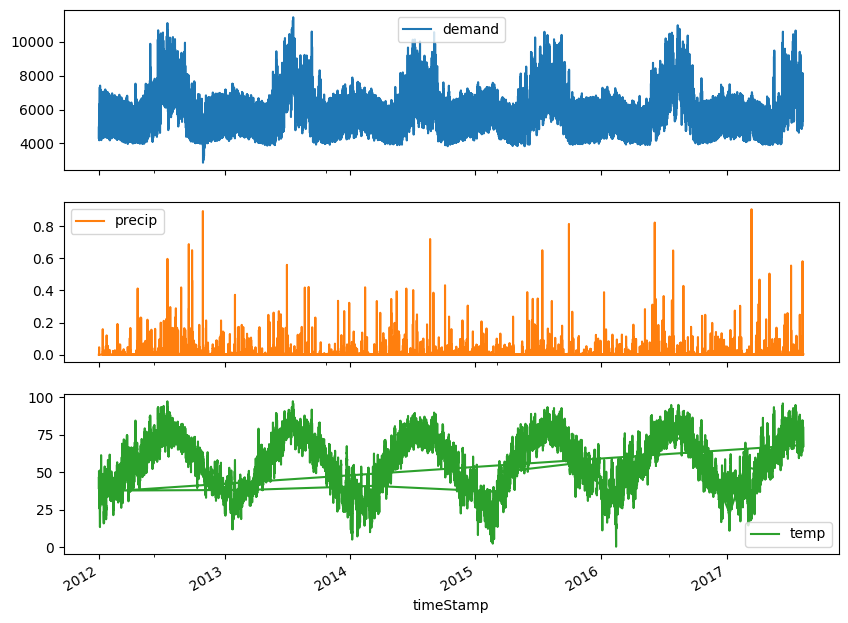

In [10]:
my_df.plot(subplots= True)

In [11]:
print("Rows. : ", df.shape[0])
print("columns :", df.shape[1])
print("\nFeatures: \n", df.columns.tolist())
print("\nMissing values : ", df.isnull().any())
print("\nUnique values : \n", df.nunique())

Rows. :  49205
columns : 4

Features: 
 ['timeStamp', 'demand', 'precip', 'temp']

Missing values :  timeStamp    False
demand        True
precip        True
temp          True
dtype: bool

Unique values : 
 timeStamp    49205
demand       40972
precip        1004
temp          7580
dtype: int64


In [12]:
df.query("demand!=demand")

,timeStamp,demand,precip,temp
49124,2012-03-11 02:00:00,NaN,0.0000,37.78
49125,2013-03-10 02:00:00,NaN,0.0000,38.18
49126,2014-03-09 02:00:00,NaN,0.0000,40.86
49127,2015-03-08 02:00:00,NaN,0.0000,36.96
49128,2015-03-11 11:00:00,NaN,0.0000,49.95
...,...,...,...,...
49200,2017-08-12 02:00:00,NaN,0.0000,70.84
49201,2017-08-12 03:00:00,NaN,0.0000,70.57
49202,2017-08-12 04:00:00,NaN,0.0000,69.89
49203,2017-08-12 05:00:00,NaN,0.0000,68.59


In [13]:
## forward fill
df["demand"] = df['demand'].fillna(method='ffill')
df['temp'] = df['temp'].fillna(method='ffill')


/var/folders/4b/f46tx7f94tddgdzqfc22ctw80000gn/T/ipykernel_15560/4063009286.py:2: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.

/var/folders/4b/f46tx7f94tddgdzqfc22ctw80000gn/T/ipykernel_15560/4063009286.py:3: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



In [14]:
print("\nMissing Values : ", df.isnull().any())


Missing Values :  timeStamp    False
demand       False
precip        True
temp         False
dtype: bool


array([<Axes: xlabel='timeStamp'>, <Axes: xlabel='timeStamp'>,
       <Axes: xlabel='timeStamp'>], dtype=object)

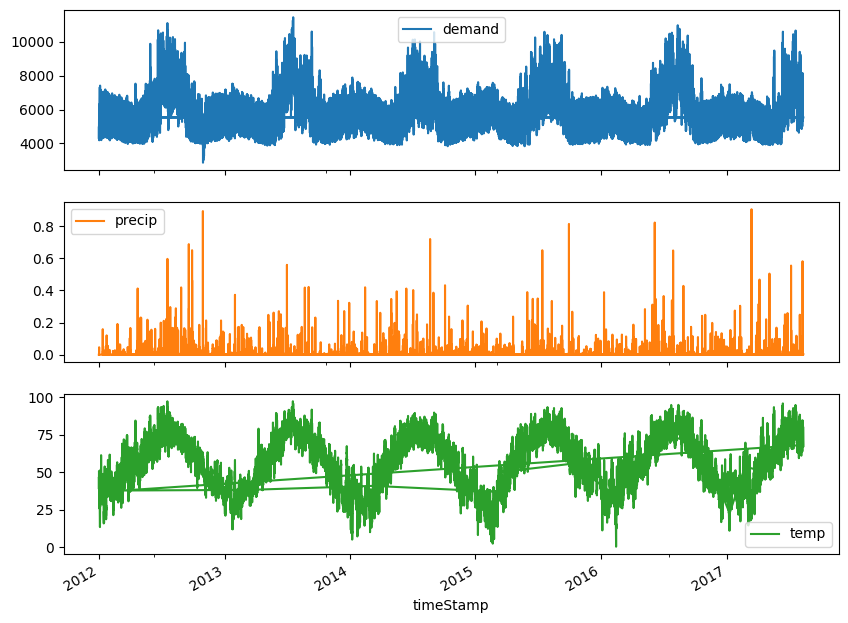

In [15]:
my_df = df.set_index('timeStamp')
my_df.plot(subplots=True)

In [16]:
my_df.resample('ME').mean()

,demand,precip,temp
timeStamp,,,
2012-01-31,5757.495833,0.003116,37.174288
2012-02-29,5622.331609,0.001650,40.448046
2012-03-31,5479.919198,0.001179,49.607917
2012-04-30,5368.945833,0.003959,54.255903
2012-05-31,5867.896102,0.005064,64.188078
...,...,...,...
2017-04-30,5233.477382,0.002942,55.621764
2017-05-31,5421.773060,0.004031,61.115457
2017-06-30,6597.990346,0.003008,71.962625


array([<Axes: xlabel='timeStamp'>, <Axes: xlabel='timeStamp'>,
       <Axes: xlabel='timeStamp'>], dtype=object)

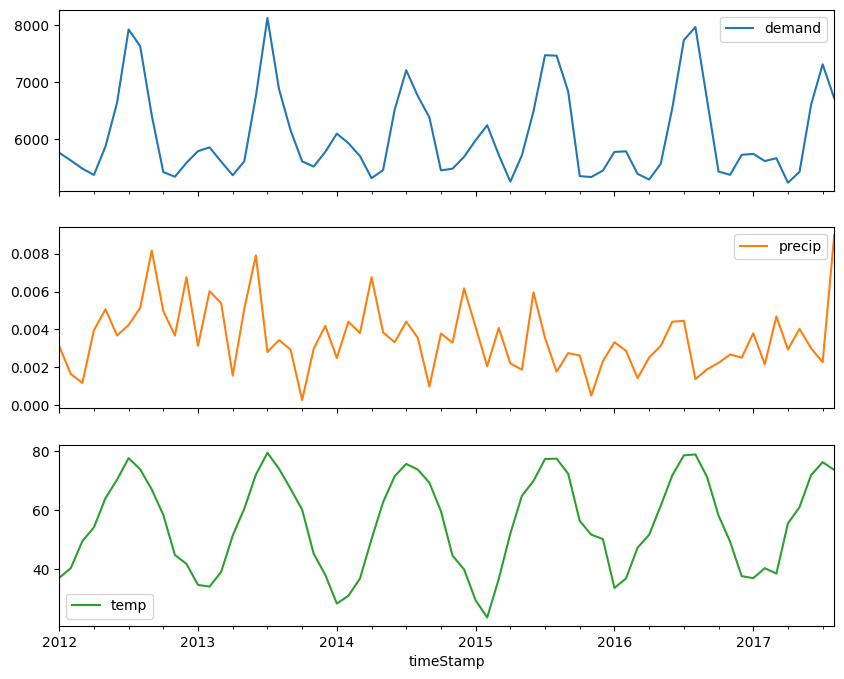

In [17]:
my_df.resample('ME').mean().plot(subplots=True)

In [18]:
my_df_monthly = my_df.resample('ME').mean()

In [19]:
!pip install pmdarima

In [20]:
my_df_monthly

,demand,precip,temp
timeStamp,,,
2012-01-31,5757.495833,0.003116,37.174288
2012-02-29,5622.331609,0.001650,40.448046
2012-03-31,5479.919198,0.001179,49.607917
2012-04-30,5368.945833,0.003959,54.255903
2012-05-31,5867.896102,0.005064,64.188078
...,...,...,...
2017-04-30,5233.477382,0.002942,55.621764
2017-05-31,5421.773060,0.004031,61.115457
2017-06-30,6597.990346,0.003008,71.962625


In [22]:
import pmdarima as pm

In [23]:

model = pm.auto_arima(my_df_monthly['demand'],
                      m=12, seasonal = True,
                      start_p=0, start_q=0, max_order=4, test='adf', error_action='ignore',
                        suppress_warnings=True,
                         stepwise=True, trace=True )


/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/pytho

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.22 sec


/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=1100.321, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=1023.727, Time=0.20 sec


/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=inf, Time=0.04 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=1380.758, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=1065.516, Time=0.01 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=1022.326, Time=0.30 sec


/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=inf, Time=0.52 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.08 sec
 ARIMA(0,0,0)(2,0,0)[12] intercept   : AIC=1097.636, Time=0.12 sec


/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(2,0,0)(2,0,0)[12] intercept   : AIC=1013.844, Time=0.31 sec
 ARIMA(2,0,0)(1,0,0)[12] intercept   : AIC=1014.001, Time=0.12 sec


/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(2,0,0)(2,0,1)[12] intercept   : AIC=inf, Time=0.42 sec
 ARIMA(2,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=nan sec


/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(3,0,0)(2,0,0)[12] intercept   : AIC=1011.617, Time=0.39 sec
 ARIMA(3,0,0)(1,0,0)[12] intercept   : AIC=1010.772, Time=0.16 sec
 ARIMA(3,0,0)(0,0,0)[12] intercept   : AIC=1022.778, Time=0.01 sec


/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(3,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=nan sec
 ARIMA(3,0,0)(0,0,1)[12] intercept   : AIC=999.713, Time=0.11 sec


/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(3,0,0)(0,0,2)[12] intercept   : AIC=995.445, Time=0.23 sec


/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(3,0,0)(1,0,2)[12] intercept   : AIC=1006.777, Time=0.38 sec


/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(2,0,0)(0,0,2)[12] intercept   : AIC=993.144, Time=0.29 sec
 ARIMA(2,0,0)(0,0,1)[12] intercept   : AIC=997.347, Time=0.08 sec


/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(2,0,0)(1,0,2)[12] intercept   : AIC=995.136, Time=0.29 sec
 ARIMA(1,0,0)(0,0,2)[12] intercept   : AIC=inf, Time=0.16 sec


/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(2,0,1)(0,0,2)[12] intercept   : AIC=994.749, Time=0.52 sec


/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(1,0,1)(0,0,2)[12] intercept   : AIC=1000.737, Time=0.21 sec


/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(3,0,1)(0,0,2)[12] intercept   : AIC=998.340, Time=0.67 sec


/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(2,0,0)(0,0,2)[12]             : AIC=inf, Time=0.59 sec

Best model:  ARIMA(2,0,0)(0,0,2)[12] intercept
Total fit time: 6.930 seconds


In [24]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                        SARIMAX Results                                        
===============================================================================================
Dep. Variable:                                       y   No. Observations:                   68
Model:             SARIMAX(2, 0, 0)x(0, 0, [1, 2], 12)   Log Likelihood                -490.572
Date:                                 Fri, 18 Jul 2025   AIC                            993.144
Time:                                         18:03:19   BIC                           1006.461
Sample:                                     01-31-2012   HQIC                           998.420
                                          - 08-31-2017                                         
Covariance Type:                                   opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   3721.6223    792.261      4.697      0.000    2168.819    5274.426
ar.L1          0.8586      0.123      6.985      0.000       0.618       1.099
ar.L2         -0.4748      0.142     -3.352      0.001      -0.752      -0.197
ma.S.L12       0.8923      0.137      6.501      0.000       0.623       1.161
ma.S.L24       0.4571      0.206      2.222      0.026       0.054       0.860
sigma2      9.046e+04   1.58e+04      5.726      0.000    5.95e+04    1.21e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 5.55
Prob(Q):                              0.89   Prob(JB):                         0.06
Heteroskedasticity (H):               0.78   Skew:                             0.52
Prob(H) (two-sided):                  0.55   Kurtosis:                         3.94
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [25]:
my_df_monthly

,demand,precip,temp
timeStamp,,,
2012-01-31,5757.495833,0.003116,37.174288
2012-02-29,5622.331609,0.001650,40.448046
2012-03-31,5479.919198,0.001179,49.607917
2012-04-30,5368.945833,0.003959,54.255903
2012-05-31,5867.896102,0.005064,64.188078
...,...,...,...
2017-04-30,5233.477382,0.002942,55.621764
2017-05-31,5421.773060,0.004031,61.115457
2017-06-30,6597.990346,0.003008,71.962625


In [27]:
train = my_df_monthly[(my_df_monthly.index.get_level_values(0) >='2012-01-31') & (my_df_monthly.index.get_level_values(0) <='2017-04-30')]

test = my_df_monthly[(my_df_monthly.index.get_level_values(0)> '2017-04-30')]

In [28]:
test

,demand,precip,temp
timeStamp,,,
2017-05-31,5421.773060,0.004031,61.115457
2017-06-30,6597.990346,0.003008,71.962625
2017-07-31,7306.861511,0.002272,76.380363
2017-08-31,6711.707542,0.008961,73.730258


In [29]:
test.shape

(4, 3)

In [30]:
model.fit(train['demand'])

/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



,order,"(2, ...)"
,seasonal_order,"(0, ...)"
,start_params,None
,method,'lbfgs'
,maxiter,50
,suppress_warnings,True
,out_of_sample_size,0
,scoring,'mse'
,scoring_args,{}
,trend,None
,with_intercept,True


In [33]:
forecast = model.predict(n_periods = 4, return_conf_int = True)

/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



In [34]:
forecast

(2017-05-31    5320.832749
 2017-06-30    6194.150586
 2017-07-31    7184.108162
 2017-08-31    7297.999644
 Freq: ME, dtype: float64,
 array([[4724.37019533, 5917.29530278],
        [5391.43562586, 6996.86554687],
        [6358.62000547, 8009.59631948],
        [6467.74939971, 8128.2498883 ]]))

In [35]:
forecast_df = pd.DataFrame(forecast[0], index = test.index, columns = ['Prediction'])

In [36]:
forecast_df

,Prediction
timeStamp,
2017-05-31,5320.832749
2017-06-30,6194.150586
2017-07-31,7184.108162
2017-08-31,7297.999644


<Axes: xlabel='timeStamp'>

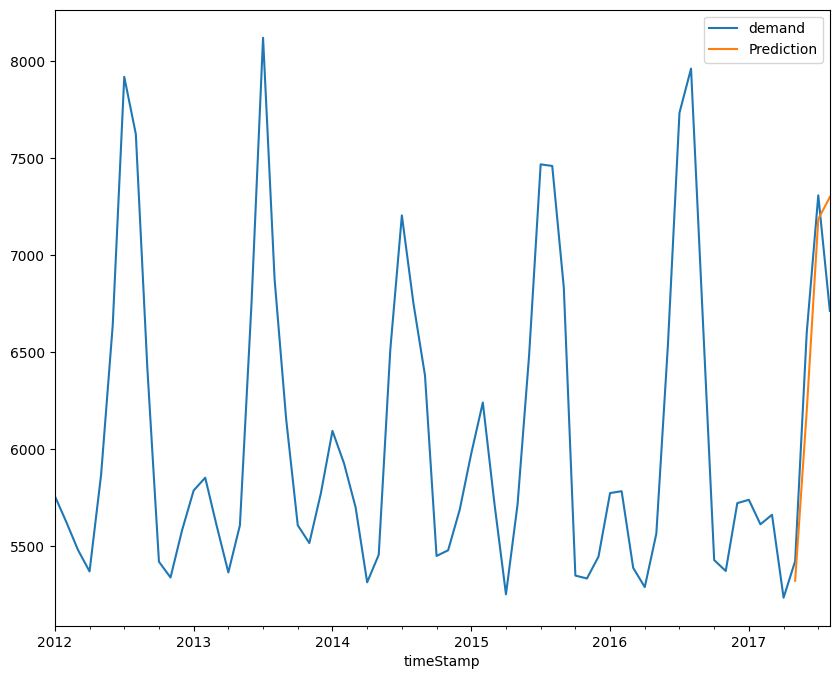

In [37]:
pd.concat([my_df_monthly['demand'], forecast_df], axis=1).plot()

In [38]:
forecast1 = model.predict(n_periods=8, return_conf_int=True)

/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/anshugangwar/Desktop/Anshu/Data Science Portfolio/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



In [43]:
forecast1

(2017-05-31    5320.832749
 2017-06-30    6194.150586
 2017-07-31    7184.108162
 2017-08-31    7297.999644
 2017-09-30    6401.927283
 2017-10-31    5789.924208
 2017-11-30    5693.039631
 2017-12-31    5951.573101
 Freq: ME, dtype: float64,
 array([[4724.37019533, 5917.29530278],
        [5391.43562586, 6996.86554687],
        [6358.62000547, 8009.59631948],
        [6467.74939971, 8128.2498883 ],
        [5553.64734048, 7250.20722555],
        [4934.10754599, 6645.74087021],
        [4837.08541204, 6548.99384925],
        [5094.94724826, 6808.19895412]]))

In [41]:
forecast_range = pd.date_range(start='2017-05-31', periods=8, freq = 'M')

/var/folders/4b/f46tx7f94tddgdzqfc22ctw80000gn/T/ipykernel_15560/194842759.py:1: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



In [45]:
forecast1_df = pd.DataFrame(forecast1[0], index = forecast_range, columns=['Prediction'])

<Axes: >

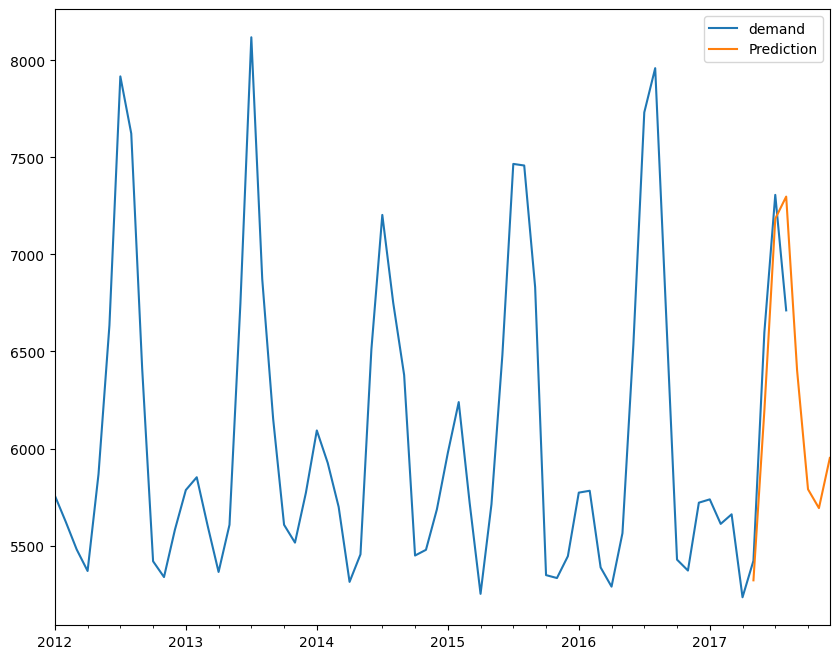

In [46]:
pd.concat([my_df_monthly['demand'], forecast1_df], axis=1).plot()

In [49]:
forecast1[1]

array([[4724.37019533, 5917.29530278],
       [5391.43562586, 6996.86554687],
       [6358.62000547, 8009.59631948],
       [6467.74939971, 8128.2498883 ],
       [5553.64734048, 7250.20722555],
       [4934.10754599, 6645.74087021],
       [4837.08541204, 6548.99384925],
       [5094.94724826, 6808.19895412]])

In [48]:
lower = pd.Series(forecast1[1][:,0], index = forecast_range)
upper = pd.Series(forecast1[1][:,1], index= forecast_range)

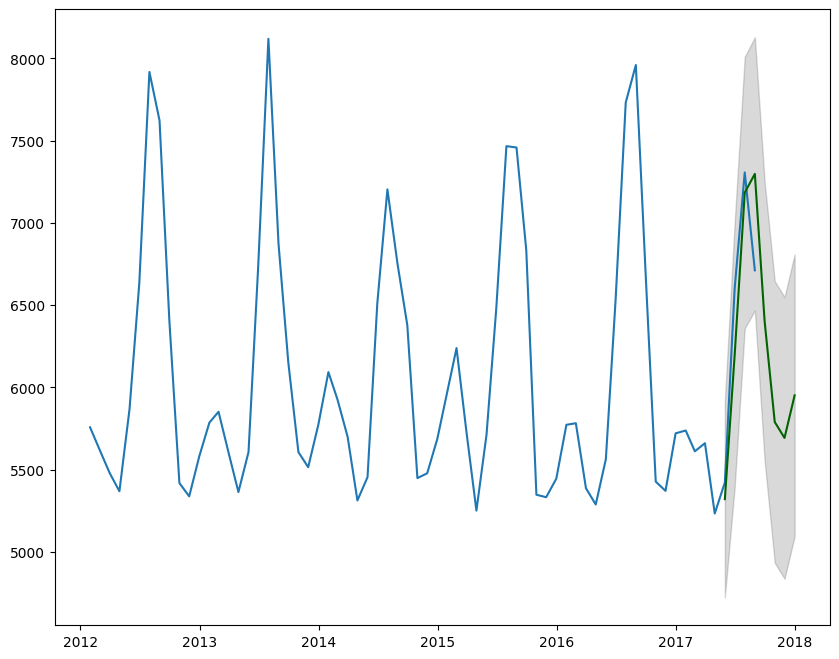

In [50]:
plt.plot(my_df_monthly['demand'])
plt.plot(forecast1_df, color='darkgreen')
plt.fill_between(forecast_range, lower, upper, color='k', alpha=.15)

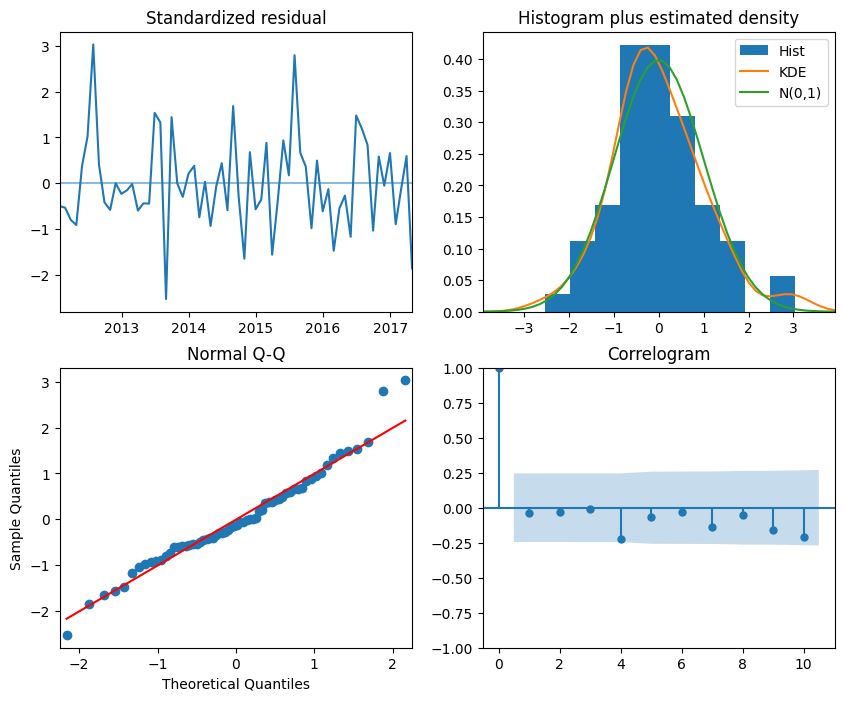

In [51]:
out = model.plot_diagnostics()